In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

This cell loads all the libraries we need before starting anything. torch and torch.nn are used to build and train the neural network. PIL and torchvision handle image loading and preprocessing. matplotlib is for plotting results. sklearn helps with splitting the dataset, and skimage gives us PSNR and SSIM to measure model quality at the end.


In [2]:
dataset_path = "/home/btech01_06/Downloads/DL_Dataset/DL_Dataset"
low_path = os.path.join(dataset_path, "low")
high_path = os.path.join(dataset_path, "high")

low_images = sorted(os.listdir(low_path))
high_images = sorted(os.listdir(high_path))

print("Low images:", len(low_images))
print("High images:", len(high_images))

Low images: 2290
High images: 2290


Here we point the code to the folder where our images are stored. The dataset has two folders low (dark images) and high (bright images). We list all the filenames from both folders and print how many images exist in each. This confirms the dataset is loaded correctly before we do anything else.

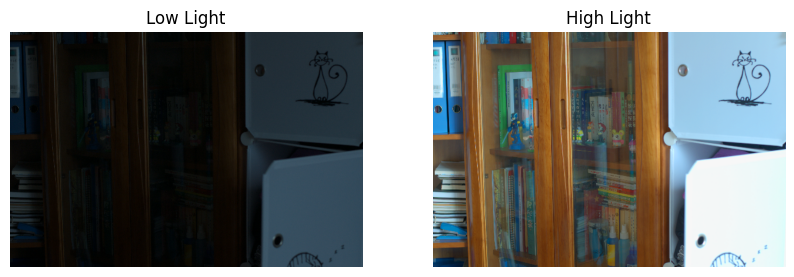

In [3]:
low_img = Image.open(os.path.join(low_path, low_images[0])).convert("RGB")
high_img = Image.open(os.path.join(high_path, high_images[0])).convert("RGB")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(low_img)
plt.title("Low Light")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(high_img)
plt.title("High Light")
plt.axis("off")

plt.show()

Before training, it's good practice to visually check that the data looks correct. This cell opens the first dark image and its corresponding bright image and displays them side by side. It confirms that the low and high images are properly paired and the files are readable.

In [4]:
indices = list(range(len(low_images)))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_low = [low_images[i] for i in train_idx]
train_high = [high_images[i] for i in train_idx]

val_low = [low_images[i] for i in val_idx]
val_high = [high_images[i] for i in val_idx]

test_low = [low_images[i] for i in test_idx]
test_high = [high_images[i] for i in test_idx]

print("Train:", len(train_low))
print("Val:", len(val_low))
print("Test:", len(test_low))

Train: 1603
Val: 343
Test: 344


We split all image indices into three groups — 70% for training, 15% for validation, and 15% for testing. random_state=42 ensures the split is the same every time we run the code. Training data is used to learn, validation data is used to monitor progress during training, and test data is used only at the very end to measure final performance.

In [5]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

All images need to be in the same format before feeding them into the model. This transform resizes every image to 256×256 pixels, converts it to a tensor, and normalizes pixel values from [0, 1] to [-1, 1]. Normalization is done because the Generator's last layer uses Tanh, which also outputs values in the [-1, 1] range — so inputs and outputs need to match.

In [6]:
class PairedDataset(Dataset):
    def __init__(self, low_list, high_list, low_dir, high_dir, transform=None):
        self.low_list = low_list
        self.high_list = high_list
        self.low_dir = low_dir
        self.high_dir = high_dir
        self.transform = transform

    def __len__(self):
        return len(self.low_list)

    def __getitem__(self, idx):
        low_img = Image.open(os.path.join(self.low_dir, self.low_list[idx])).convert("RGB")
        high_img = Image.open(os.path.join(self.high_dir, self.high_list[idx])).convert("RGB")

        if self.transform:
            low_img = self.transform(low_img)
            high_img = self.transform(high_img)

        return low_img, high_img

This class tells PyTorch how to load one image pair at a time. When the DataLoader asks for item number idx, this class opens the dark image and its matching bright image, applies the transform to both, and returns them together as a pair. This ensures that the dark and bright images always stay matched during training.

In [7]:
train_dataset = PairedDataset(train_low, train_high, low_path, high_path, transform)
val_dataset = PairedDataset(val_low, val_high, low_path, high_path, transform)
test_dataset = PairedDataset(test_low, test_high, low_path, high_path, transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 400
Val batches: 86
Test batches: 86


Here we create three datasets (train, val, test) using the class defined above, and wrap each in a DataLoader. The DataLoader handles batching — instead of feeding one image at a time, it feeds 4 images together (batch_size=4). shuffle=True for training means images are fed in a random order each epoch, which helps the model learn more robustly.

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, n_residuals=6):
        super().__init__()

        layers = [
            nn.Conv2d(in_channels, 64, 7, 1, 3),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.InstanceNorm2d(256),
            nn.ReLU(inplace=True)
        ]

        for _ in range(n_residuals):
            layers.append(ResidualBlock(256))

        layers += [
            nn.ConvTranspose2d(256, 128, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, out_channels, 7, 1, 3),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

ResidualBlock: Each residual block applies two convolutions to the input and then adds the original input back to the result (x + self.block(x)). This skip connection helps gradients flow during backpropagation and prevents the network from forgetting useful features learned in earlier layers.

Generator: The Generator follows an encoder-bottleneck-decoder structure. The encoder compresses the image from 256×256 down to 64×64 while increasing channels (3→64→128→256), extracting features like edges and lighting. Six residual blocks in the middle process these features at high abstraction. The decoder then upsamples back to 256×256 (256→128→64→3). The final Tanh activation outputs pixel values in [-1, 1] to match the normalized input range.

In [9]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 1, 1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, x):
        return self.model(x)

The Discriminator is a PatchGAN, instead of giving one score for the whole image, it outputs a 30×30 map where each value scores a different 70×70 patch of the image. This forces the Generator to make every region of the image look realistic, not just the overall image. LeakyReLU is used instead of ReLU so that small negative values still pass through, giving better gradient flow for the Discriminator during training.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G_AB = Generator().to(device)
G_BA = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

print("Using device:", device)

Using device: cuda


CycleGAN requires four networks. G_AB converts dark images to bright, G_BA converts bright images to dark, D_A judges whether a dark image is real or fake, and D_B judges whether a bright image is real or fake. All four are moved to the GPU using .to(device) so that training runs significantly faster than on CPU.

In [11]:
criterion_gan = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()
criterion_supervised = nn.L1Loss()

Four loss functions are defined, each measuring a different thing. criterion_gan uses MSELoss for adversarial training between Generator and Discriminator. criterion_cycle uses L1Loss to enforce that the round-trip translation (dark→bright→dark) reconstructs the original. criterion_identity uses L1Loss to ensure the Generator doesn't change an image that's already in the target domain. criterion_supervised uses L1Loss to directly compare the Generator's output with the ground-truth bright image.

In [12]:
optimizer_G = optim.Adam(
    list(G_AB.parameters()) + list(G_BA.parameters()),
    lr=0.0002,
    betas=(0.5, 0.999),
    weight_decay=1e-5
)

optimizer_D_A = optim.Adam(
    D_A.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999),
    weight_decay=1e-5
)

optimizer_D_B = optim.Adam(
    D_B.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999),
    weight_decay=1e-5
)

Three Adam optimizers are created one for both generators together and one for each discriminator. Both generators share a single optimizer because their losses are combined and they are updated in one step. Adam with lr=0.0002 and betas=(0.5, 0.999) is the standard choice for GAN training it adapts the learning rate per parameter and reacts quickly to gradient changes. weight_decay=1e-5 adds mild regularization to prevent overfitting.

In [13]:
def real_labels(pred):
    return torch.ones_like(pred)

def fake_labels(pred):
    return torch.zeros_like(pred)


def evaluate_generator(generator, loader, device):
    generator.eval()
    val_loss = 0.0

    with torch.no_grad():
        for low, high in loader:
            low = low.to(device)
            high = high.to(device)

            fake_high = generator(low)
            loss = criterion_supervised(fake_high, high)
            val_loss += loss.item()

    return val_loss / len(loader)

real_labels and fake_labels create label tensors matching the shape of the Discriminator's output, all ones for real images and all zeros for fake images. These are needed because the Discriminator outputs a 30×30 patch map, not a single number. evaluate_generator runs the Generator on the validation set without updating any weights and returns the average L1 loss, which is used to track whether the model is improving on unseen images.

In [14]:
num_epochs = 150
lambda_cycle = 10
lambda_identity = 5
lambda_supervised = 10

patience = 15
best_val_loss = float("inf")
early_stop_counter = 0

g_losses = []
d_losses = []
val_losses = []

This cell sets the key values that define how training runs. num_epochs=150 sets the maximum training duration. lambda_cycle=10 and lambda_supervised=10 are set high because cycle-consistency and ground-truth matching are the most critical objectives. lambda_identity=5 is lower since identity preservation is a secondary concern. patience=15 means training will stop early if validation loss doesn't improve for 15 consecutive epochs, saving time and preventing overfitting.

In [15]:
for epoch in range(num_epochs):
    G_AB.train()
    G_BA.train()
    D_A.train()
    D_B.train()

    running_g = 0.0
    running_d = 0.0

    for real_A, real_B in train_loader:
        real_A = real_A.to(device)
        real_B = real_B.to(device)

        # ---------------- Generator ----------------
        optimizer_G.zero_grad()

        same_B = G_AB(real_B)
        loss_identity_B = criterion_identity(same_B, real_B) * lambda_identity

        same_A = G_BA(real_A)
        loss_identity_A = criterion_identity(same_A, real_A) * lambda_identity

        fake_B = G_AB(real_A)
        pred_fake_B = D_B(fake_B)
        loss_gan_AB = criterion_gan(pred_fake_B, real_labels(pred_fake_B))

        fake_A = G_BA(real_B)
        pred_fake_A = D_A(fake_A)
        loss_gan_BA = criterion_gan(pred_fake_A, real_labels(pred_fake_A))

        recov_A = G_BA(fake_B)
        loss_cycle_A = criterion_cycle(recov_A, real_A) * lambda_cycle

        recov_B = G_AB(fake_A)
        loss_cycle_B = criterion_cycle(recov_B, real_B) * lambda_cycle

        loss_sup_AB = criterion_supervised(fake_B, real_B) * lambda_supervised
        loss_sup_BA = criterion_supervised(fake_A, real_A) * lambda_supervised

        loss_G = (
            loss_identity_A + loss_identity_B +
            loss_gan_AB + loss_gan_BA +
            loss_cycle_A + loss_cycle_B +
            loss_sup_AB + loss_sup_BA
        )

        loss_G.backward()
        optimizer_G.step()

        # ---------------- D_A ----------------
        optimizer_D_A.zero_grad()

        pred_real_A = D_A(real_A)
        loss_real_A = criterion_gan(pred_real_A, real_labels(pred_real_A))

        pred_fake_A = D_A(fake_A.detach())
        loss_fake_A = criterion_gan(pred_fake_A, fake_labels(pred_fake_A))

        loss_D_A = 0.5 * (loss_real_A + loss_fake_A)
        loss_D_A.backward()
        optimizer_D_A.step()

        # ---------------- D_B ----------------
        optimizer_D_B.zero_grad()

        pred_real_B = D_B(real_B)
        loss_real_B = criterion_gan(pred_real_B, real_labels(pred_real_B))

        pred_fake_B = D_B(fake_B.detach())
        loss_fake_B = criterion_gan(pred_fake_B, fake_labels(pred_fake_B))

        loss_D_B = 0.5 * (loss_real_B + loss_fake_B)
        loss_D_B.backward()
        optimizer_D_B.step()

        loss_D = loss_D_A + loss_D_B

        running_g += loss_G.item()
        running_d += loss_D.item()

    epoch_g = running_g / len(train_loader)
    epoch_d = running_d / len(train_loader)
    epoch_val = evaluate_generator(G_AB, val_loader, device)

    g_losses.append(epoch_g)
    d_losses.append(epoch_d)
    val_losses.append(epoch_val)

    if epoch_val < best_val_loss:
        best_val_loss = epoch_val
        early_stop_counter = 0
        torch.save(G_AB.state_dict(), "best_G_AB_cyclegan_150epochs.pth")
        print(f"Epoch {epoch+1}: Best model saved")
    else:
        early_stop_counter += 1

    print(f"Epoch {epoch+1}/{num_epochs} | G Loss: {epoch_g:.4f} | D Loss: {epoch_d:.4f} | Val Loss: {epoch_val:.4f}")

    if early_stop_counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1: Best model saved
Epoch 1/150 | G Loss: 13.7616 | D Loss: 0.4802 | Val Loss: 0.3501
Epoch 2/150 | G Loss: 12.2338 | D Loss: 0.3932 | Val Loss: 0.3599
Epoch 3/150 | G Loss: 11.9251 | D Loss: 0.3610 | Val Loss: 0.3580
Epoch 4/150 | G Loss: 11.5799 | D Loss: 0.3410 | Val Loss: 0.3583
Epoch 5: Best model saved
Epoch 5/150 | G Loss: 11.3827 | D Loss: 0.3237 | Val Loss: 0.3362
Epoch 6: Best model saved
Epoch 6/150 | G Loss: 11.2241 | D Loss: 0.3169 | Val Loss: 0.3324
Epoch 7: Best model saved
Epoch 7/150 | G Loss: 10.9623 | D Loss: 0.3121 | Val Loss: 0.3302
Epoch 8: Best model saved
Epoch 8/150 | G Loss: 10.7419 | D Loss: 0.3170 | Val Loss: 0.3272
Epoch 9/150 | G Loss: 10.6276 | D Loss: 0.3182 | Val Loss: 0.3458
Epoch 10/150 | G Loss: 10.4926 | D Loss: 0.4165 | Val Loss: 0.3364
Epoch 11: Best model saved
Epoch 11/150 | G Loss: 9.7598 | D Loss: 0.3982 | Val Loss: 0.3230
Epoch 12/150 | G Loss: 9.8362 | D Loss: 0.3577 | Val Loss: 0.3336
Epoch 13: Best model saved
Epoch 13/150 | G Loss: 

This is the core of the entire model. Each epoch loops over every batch and performs two updates.

Generator update: The Generator computes all four losses — identity, GAN, cycle-consistency, and supervised — adds them together into one total loss, and updates both G_AB and G_BA weights in one step.

Discriminator update: Each discriminator is trained separately to correctly score real images as 1 and fake images as 0. fake.detach() is used so that discriminator gradients don't accidentally flow back into the generator. The 0.5 factor slows discriminator updates to keep the adversarial game balanced. At the end of each epoch, validation loss is computed and if it's the best seen so far, the model is saved.

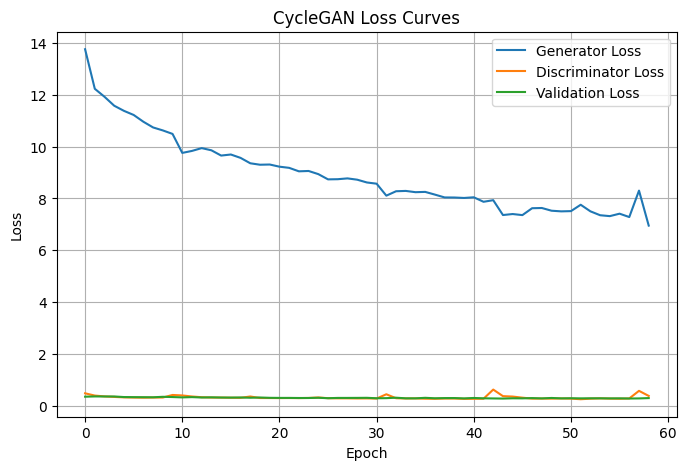

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CycleGAN Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

This cell plots the Generator loss, Discriminator loss, and Validation loss across all epochs. 
The Generator loss starts high and decreases steadily, showing the model is learning. 
The Discriminator loss stays near zero throughout, indicating a stable adversarial balance. 
The Validation loss stays low and flat, confirming the model generalises well to unseen images without overfitting.

In [17]:
G_AB.load_state_dict(torch.load("best_G_AB_cyclegan_150epochs.pth", map_location=device))
G_AB.eval()

print("Best generator loaded.")

Best generator loaded.


In [18]:
psnr_values = []
ssim_values = []

with torch.no_grad():
    for low, high in test_loader:
        low = low.to(device)
        high = high.to(device)

        fake_high = G_AB(low)

        fake_high = fake_high.cpu().permute(0, 2, 3, 1).numpy()
        high = high.cpu().permute(0, 2, 3, 1).numpy()

        fake_high = (fake_high * 0.5) + 0.5
        high = (high * 0.5) + 0.5

        fake_high = np.clip(fake_high, 0, 1)
        high = np.clip(high, 0, 1)

        for i in range(fake_high.shape[0]):
            psnr_val = peak_signal_noise_ratio(high[i], fake_high[i], data_range=1)
            ssim_val = structural_similarity(high[i], fake_high[i], channel_axis=2, data_range=1)

            psnr_values.append(psnr_val)
            ssim_values.append(ssim_val)

print("Average PSNR:", np.mean(psnr_values))
print("Average SSIM:", np.mean(ssim_values))

Average PSNR: 19.01849892062189
Average SSIM: 0.6281461


The best model is run on all test images and the outputs are compared against the ground truth bright images using two metrics. PSNR measures pixel-level accuracy and SSIM measures how well the structure and brightness are preserved. 

The model achieved an Average PSNR of 19.02 dB and Average SSIM of 0.628, which are good results for low-light image enhancement on a custom dataset. A PSNR above 18 dB indicates the enhanced images are reasonably close to the ground truth, and an SSIM above 0.6 confirms that the model is recovering structure and brightness in a meaningful way, not just randomly brightening the image.

In [19]:
with torch.no_grad():
    low_batch, high_batch = next(iter(test_loader))
    low_batch = low_batch.to(device)

    output_batch = G_AB(low_batch)

    low_batch = low_batch.cpu()
    high_batch = high_batch.cpu()
    output_batch = output_batch.cpu()

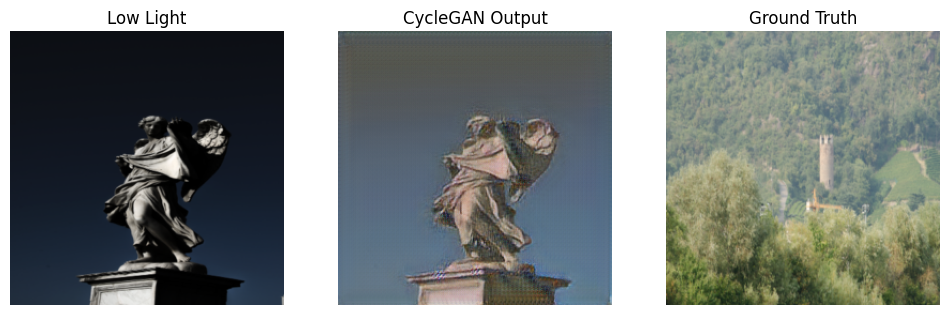

In [21]:
low_img = low_batch[0].permute(1, 2, 0).numpy()
high_img = high_batch[0].permute(1, 2, 0).numpy()
out_img = output_batch[0].permute(1, 2, 0).numpy()

low_img = np.clip((low_img * 0.5) + 0.5, 0, 1)
high_img = np.clip((high_img * 0.5) + 0.5, 0, 1)
out_img = np.clip((out_img * 0.5) + 0.5, 0, 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(low_img)
plt.title("Low Light")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(out_img)
plt.title("CycleGAN Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(high_img)
plt.title("Ground Truth")
plt.axis("off")

plt.show()

In [32]:
test_image_path = "/home/btech01_06/Downloads/image1.png"

img = Image.open(test_image_path).convert("RGB")
input_img = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = G_AB(input_img)

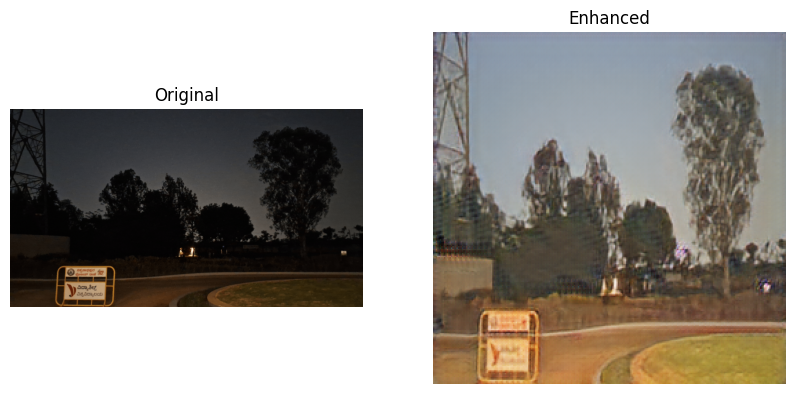

In [33]:
output = output.squeeze().cpu().permute(1, 2, 0).numpy()
output = np.clip((output * 0.5) + 0.5, 0, 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(output)
plt.title("Enhanced")
plt.axis("off")

plt.show()

In [35]:
test_image_path = "/home/btech01_06/Downloads/image2.png"

img = Image.open(test_image_path).convert("RGB")
input_img = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = G_AB(input_img)

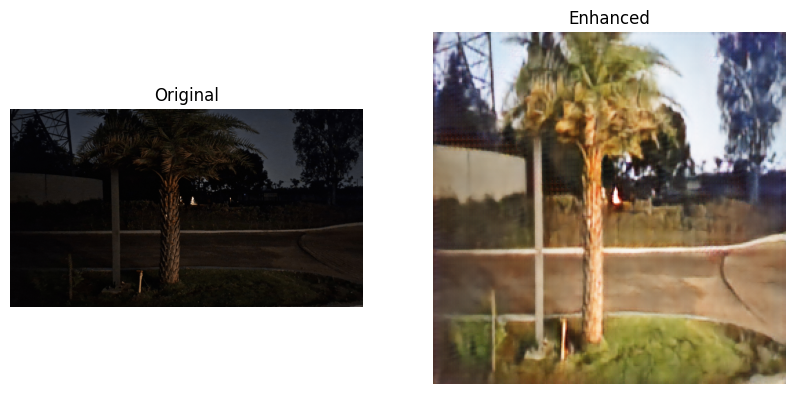

In [36]:
output = output.squeeze().cpu().permute(1, 2, 0).numpy()
output = np.clip((output * 0.5) + 0.5, 0, 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(output)
plt.title("Enhanced")
plt.axis("off")

plt.show()

In [37]:
test_image_path = "/home/btech01_06/Downloads/image3.png"

img = Image.open(test_image_path).convert("RGB")
input_img = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = G_AB(input_img)

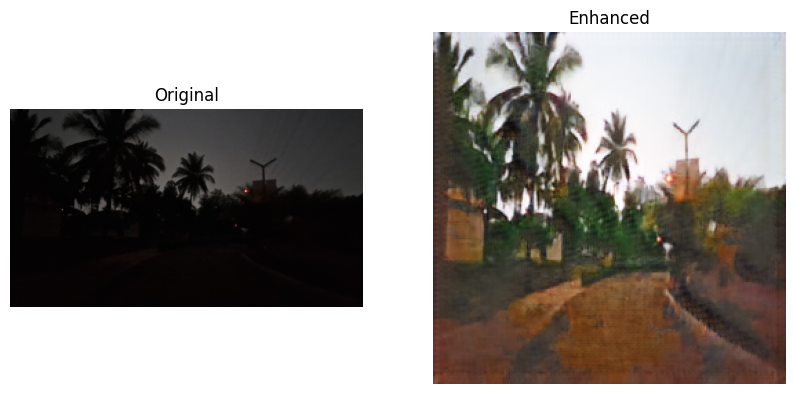

In [38]:
output = output.squeeze().cpu().permute(1, 2, 0).numpy()
output = np.clip((output * 0.5) + 0.5, 0, 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(output)
plt.title("Enhanced")
plt.axis("off")

plt.show()

In [39]:
test_image_path = "/home/btech01_06/Downloads/image4.png"

img = Image.open(test_image_path).convert("RGB")
input_img = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = G_AB(input_img)

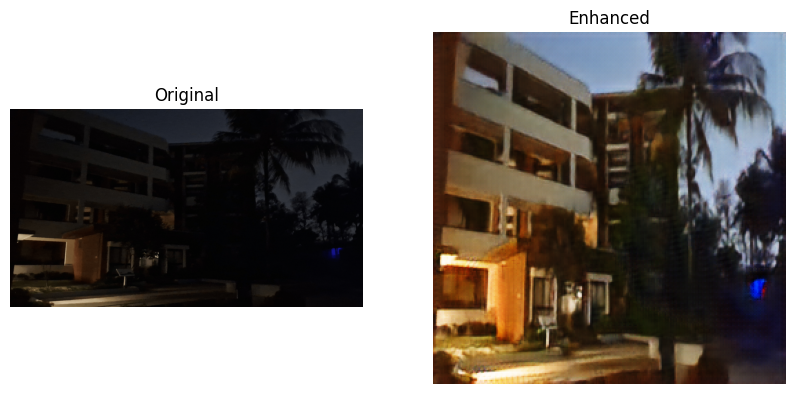

In [40]:
output = output.squeeze().cpu().permute(1, 2, 0).numpy()
output = np.clip((output * 0.5) + 0.5, 0, 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(output)
plt.title("Enhanced")
plt.axis("off")

plt.show()